# Análisis Exploratorio de Series de Tiempo
Evolución de variables clave a lo largo de las semanas gestacionales.

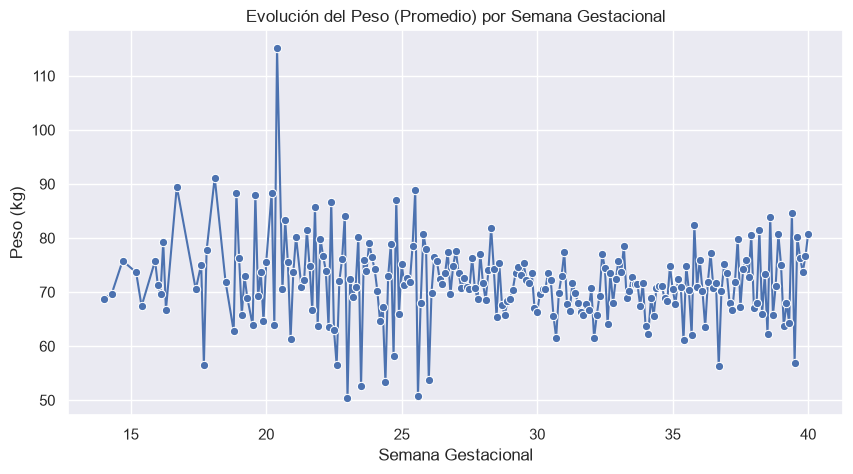

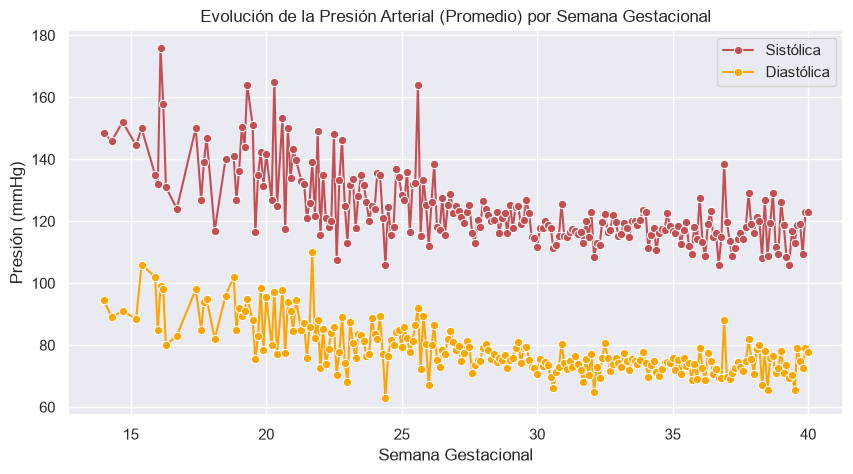

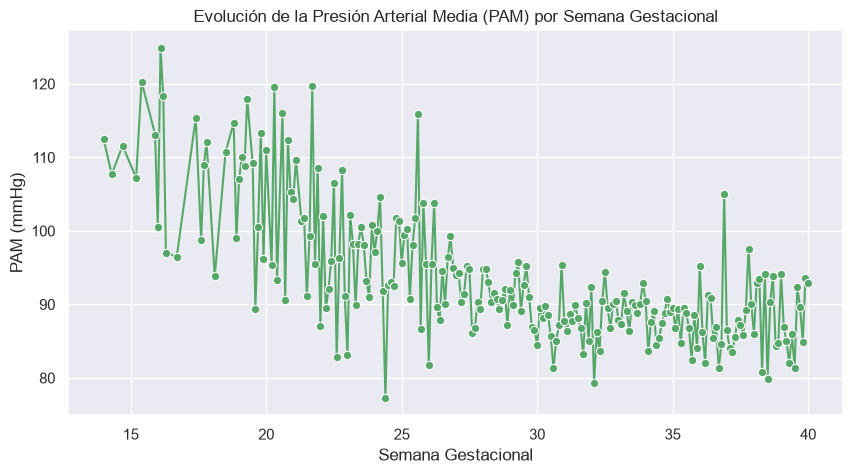

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Usamos os para resolver el path dinámicamente, asegurando que pueda leerlo
# ya sea que se ejecute desde 'time series' o desde la raíz del workspace.
current_dir = os.getcwd()
file_name = 'patient_diary.csv'
file_path = os.path.join(current_dir, file_name)

if not os.path.exists(file_path):
    file_path = os.path.join(current_dir, 'time series', file_name)
    if not os.path.exists(file_path):
        # Fallback a ruta absoluta por si acaso
        file_path = r'c:\Universidad\mineria\time series\patient_diary.csv'

df = pd.read_csv(file_path)
df_grouped = df.groupby('gestational_week').mean(numeric_only=True).reset_index()
sns.set_theme(style="darkgrid")

# Gráfica de Peso
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_grouped, x='gestational_week', y='weight_kg', marker='o', color='b')
plt.title('Evolución del Peso (Promedio) por Semana Gestacional')
plt.xlabel('Semana Gestacional')
plt.ylabel('Peso (kg)')
plt.show()

# Gráfica de Presión Arterial (Sistólica y Diastólica)
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_grouped, x='gestational_week', y='systolic', marker='o', label='Sistólica', color='r')
sns.lineplot(data=df_grouped, x='gestational_week', y='diastolic', marker='o', label='Diastólica', color='orange')
plt.title('Evolución de la Presión Arterial (Promedio) por Semana Gestacional')
plt.xlabel('Semana Gestacional')
plt.ylabel('Presión (mmHg)')
plt.legend()
plt.show()

# Gráfica de PAM
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_grouped, x='gestational_week', y='mean_arterial_pressure', marker='o', color='g')
plt.title('Evolución de la Presión Arterial Media (PAM) por Semana Gestacional')
plt.xlabel('Semana Gestacional')
plt.ylabel('PAM (mmHg)')
plt.show()


## Detección de Valores Atípicos con Isolation Forest
Identificando datos anómalos considerando la semana gestacional.

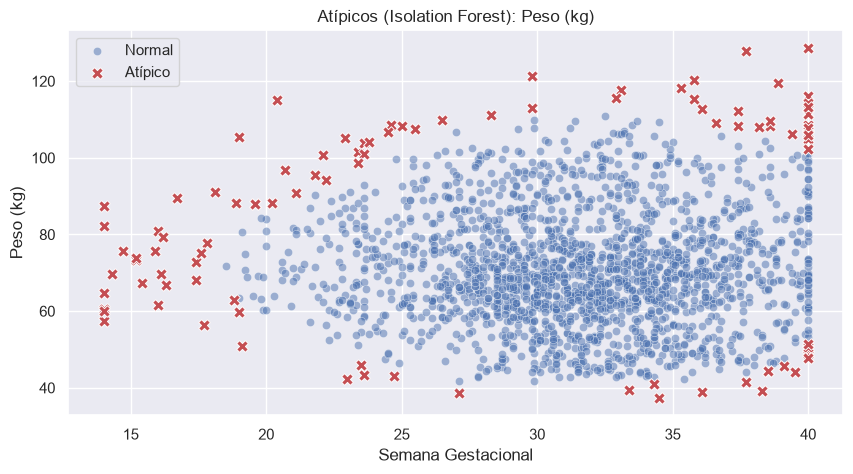

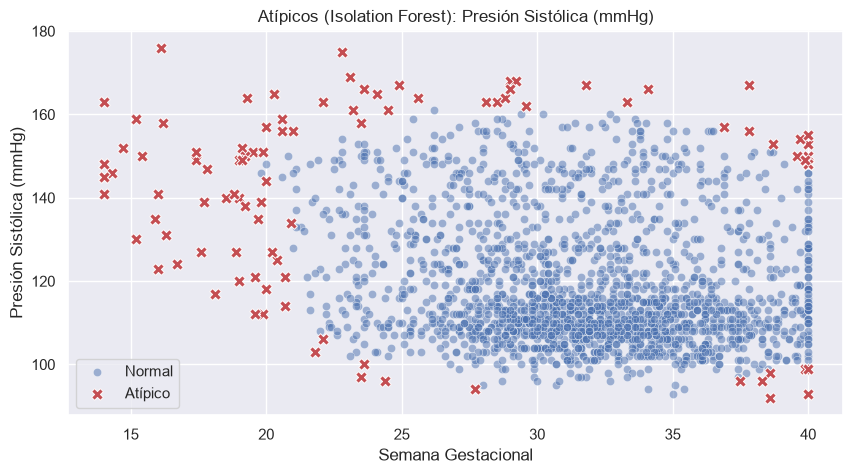

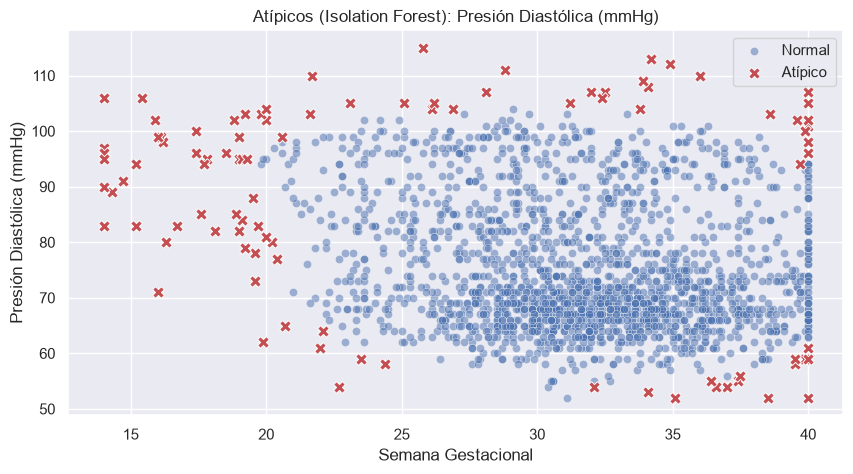

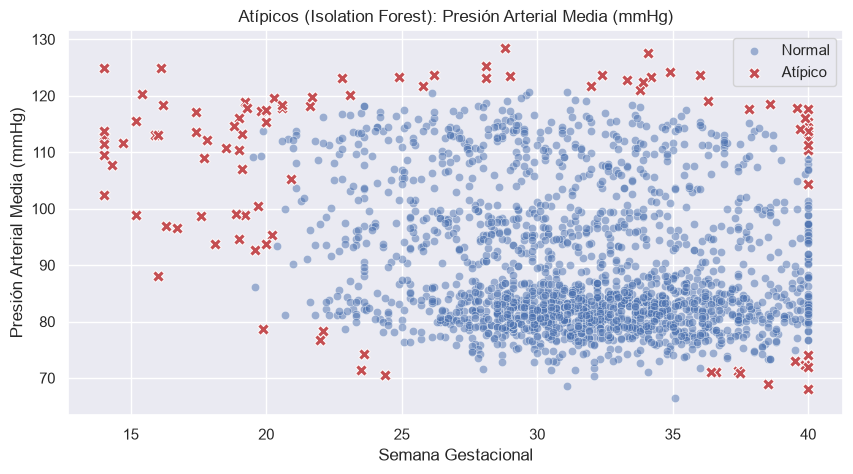

In [2]:
from sklearn.ensemble import IsolationForest

variables = ['weight_kg', 'systolic', 'diastolic', 'mean_arterial_pressure']

titles = {
    'weight_kg': 'Peso (kg)',
    'systolic': 'Presión Sistólica (mmHg)',
    'diastolic': 'Presión Diastólica (mmHg)',
    'mean_arterial_pressure': 'Presión Arterial Media (mmHg)'
}

for var in variables:
    temp_df = df[['gestational_week', var]].dropna()
    
    # Entrenar Isolation Forest (asumiendo 5% de anomalías)
    iso = IsolationForest(contamination=0.05, random_state=42)
    temp_df['anomaly'] = iso.fit_predict(temp_df[['gestational_week', var]])
    
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=temp_df[temp_df['anomaly'] == 1], x='gestational_week', y=var, color='b', label='Normal', alpha=0.5)
    sns.scatterplot(data=temp_df[temp_df['anomaly'] == -1], x='gestational_week', y=var, color='r', label='Atípico', s=70, marker='X')
    
    plt.title(f'Atípicos (Isolation Forest): {titles[var]}')
    plt.xlabel('Semana Gestacional')
    plt.ylabel(titles[var])
    plt.legend()
    plt.show()


## Descomposición de Series de Tiempo (Aditiva)\nUsamos la columna `created_at` generada para agrupar los datos temporalmente por semana y separar la tendencia, estacionalidad y los residuos.

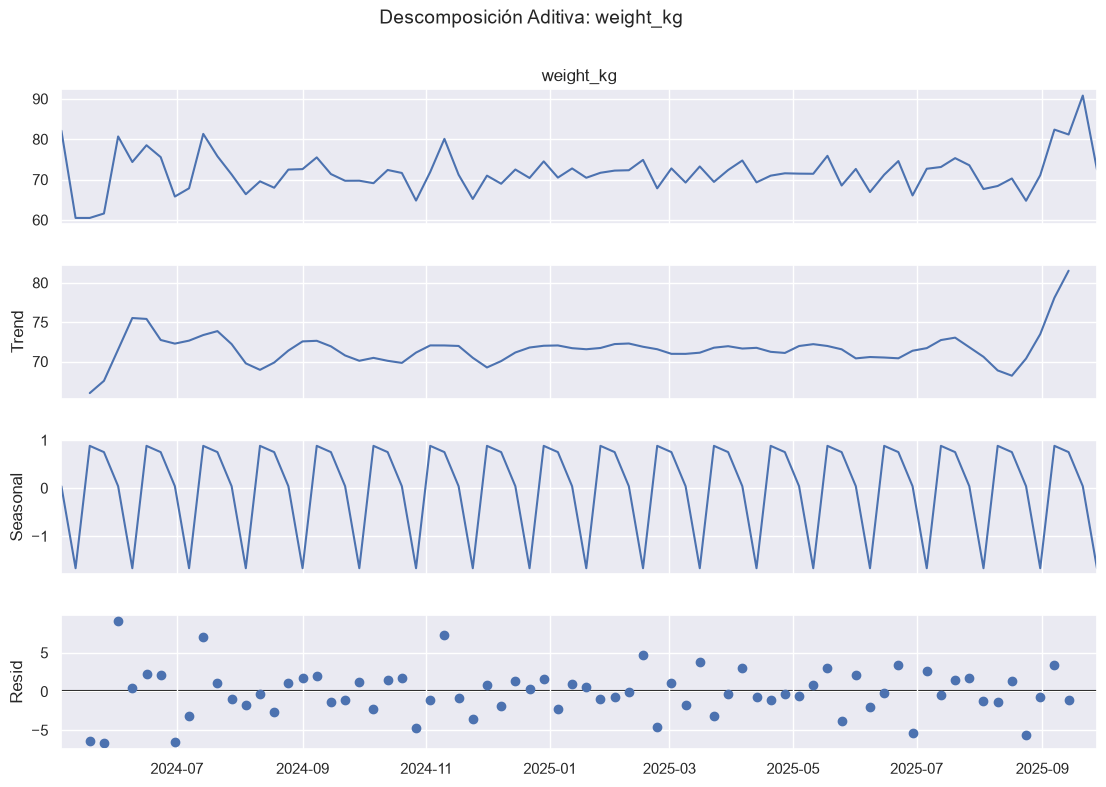

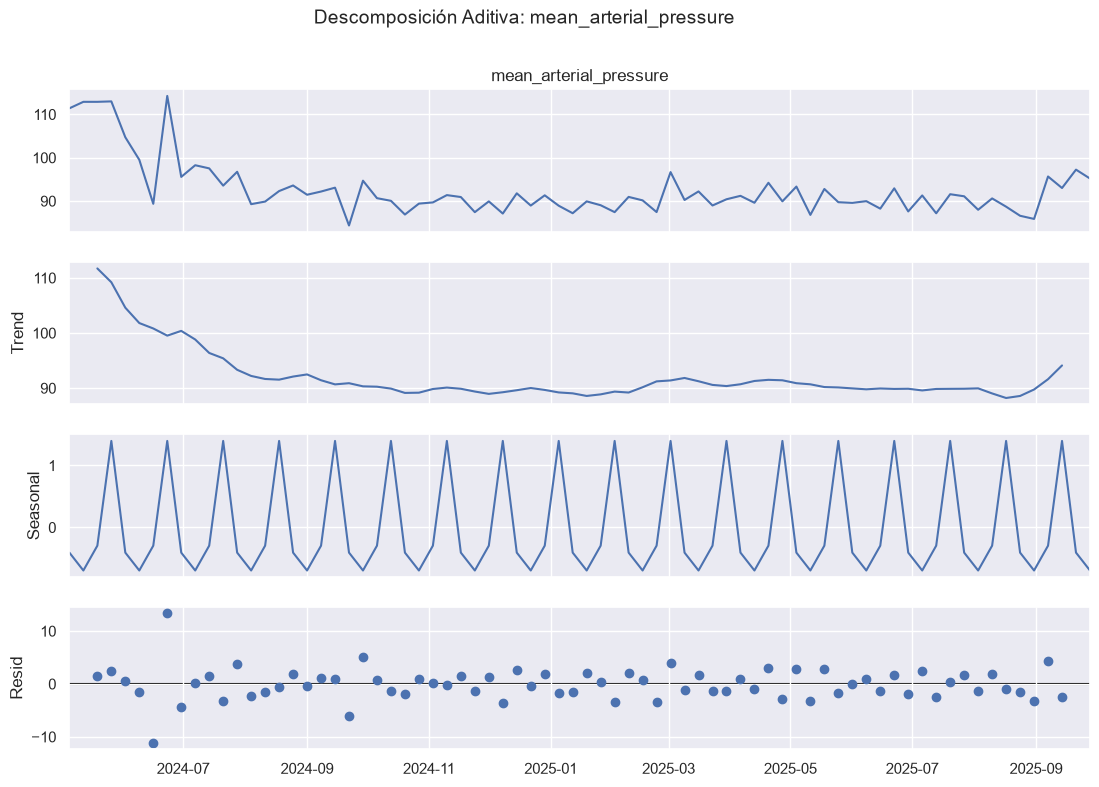

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Convertir a datetime y ordenar
df['created_at'] = pd.to_datetime(df['created_at'])
df_ts = df.set_index('created_at').sort_index()

# Remuestrear los datos de forma semanal ('W') y calcular el promedio. 
# Usamos forward fill (ffill) para llenar semanas sin datos.
df_weekly = df_ts[['weight_kg', 'systolic', 'diastolic', 'mean_arterial_pressure']].resample('W').mean().ffill().bfill()

variables = ['weight_kg', 'mean_arterial_pressure']

for var in variables:
    # Aplicar la descomposición aditiva asumiendo una frecuencia de 4 semanas (aprox. 1 mes)
    result = seasonal_decompose(df_weekly[var], model='additive', period=4)
    
    fig = result.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle(f'Descomposición Aditiva: {var}', fontsize=14, y=1.02)
    plt.show()


## Predicción con Suavizado Exponencial\nModelos de 1er grado (Simple), 2do grado (Holt) y 3er grado (Holt-Winters) para predecir las próximas 8 semanas.

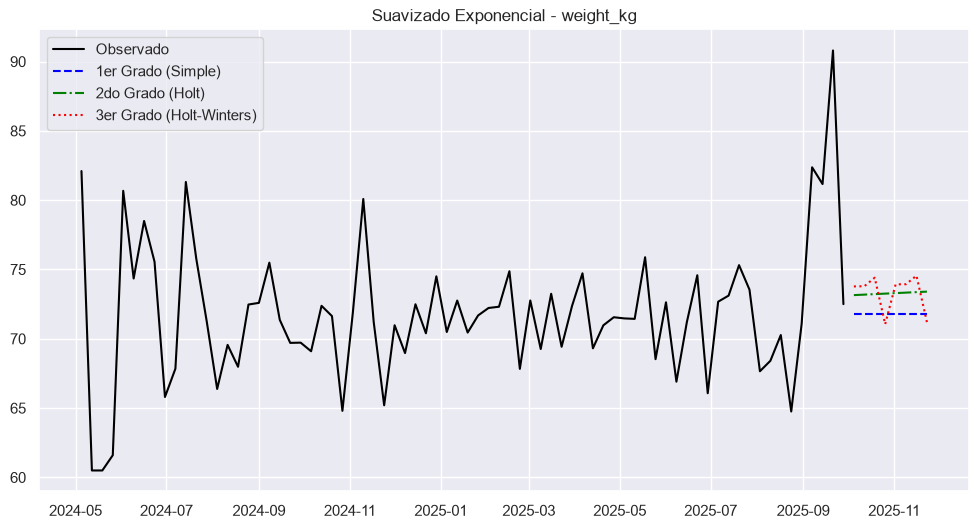

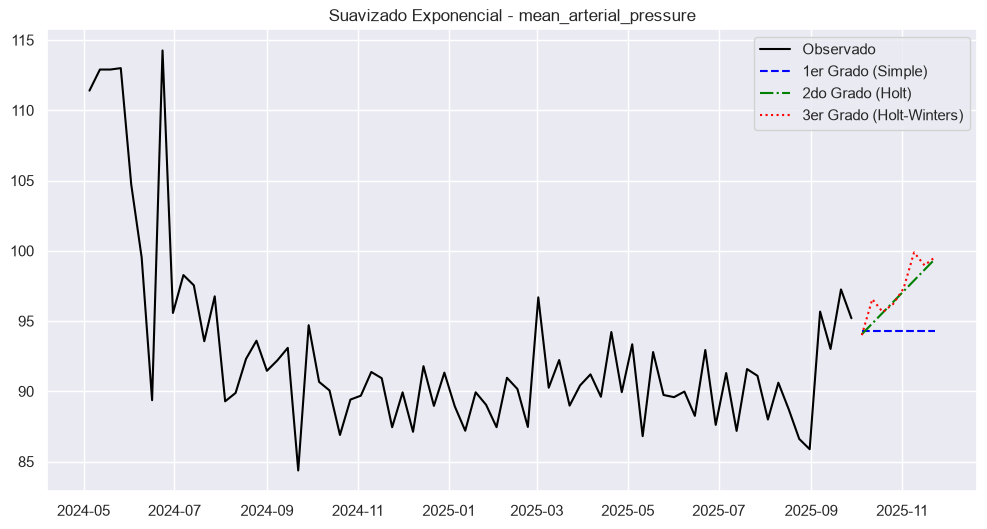

In [4]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

for var in variables:
    ts = df_weekly[var]
    
    # 1er Grado: Simple Exponential Smoothing
    fit1 = SimpleExpSmoothing(ts, initialization_method="estimated").fit()
    fcast1 = fit1.forecast(8)
    
    # 2do Grado: Holt's Linear Trend
    fit2 = Holt(ts, initialization_method="estimated").fit()
    fcast2 = fit2.forecast(8)
    
    # 3er Grado: Holt-Winters (Tendencia + Estacionalidad)
    # Asumimos periodos de 4 semanas (1 mes)
    fit3 = ExponentialSmoothing(ts, trend='add', seasonal='add', seasonal_periods=4, initialization_method="estimated").fit()
    fcast3 = fit3.forecast(8)
    
    plt.figure(figsize=(12, 6))
    plt.plot(ts, label='Observado', color='black')
    plt.plot(fcast1, label='1er Grado (Simple)', color='blue', linestyle='--')
    plt.plot(fcast2, label='2do Grado (Holt)', color='green', linestyle='-.')
    plt.plot(fcast3, label='3er Grado (Holt-Winters)', color='red', linestyle=':')
    
    plt.title(f'Suavizado Exponencial - {var}')
    plt.legend()
    plt.show()
